In [9]:
import numpy as np
import pandas as pd 
from pathlib import Path
from multiprocessing import Pool

import matplotlib.pyplot as plt
%matplotlib widget

import seaborn as sns

import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, average_precision_score
from sklearn.metrics import f1_score, balanced_accuracy_score
from scipy.stats import gaussian_kde, linregress
from scipy.optimize import minimize_scalar

from tqdm.auto import tqdm
tqdm.pandas()

THRESHOLD = 0.5

In [2]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds' / 'predictions-probs.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')

predictions_sr = (predictions > THRESHOLD).sum(axis=1)
predictions_prev = (predictions > THRESHOLD).sum(axis=0)

In [ ]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
fulldf = pd.read_csv(p, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
targets = fulldf.loc[fulldf['subset'] == 'test', predictions.columns]

# Test dataset summary
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

## Outputs visualization

#### Species richness

In [10]:
print(linregress(targets_sr, predictions_sr))

LinregressResult(slope=0.8377703120012339, intercept=3.528466904967278, rvalue=0.6807818699171936, pvalue=0.0, stderr=0.012810614830251123, intercept_stderr=0.3653002066728311)


In [11]:
# fig = px.scatter(
#     x=np.log(1+targets_sr), y=np.log(1+predictions_sr),
#     marginal_y='violin', marginal_x='violin'
# )
fig = px.scatter(
    x=targets_sr, y=predictions_sr,
    marginal_y='violin', marginal_x='violin'
)
fig.update_layout(width=800, height=800)
fig.show()

#### Threshold optimization

In [15]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    return np.abs(sr.mean() - target_sr.mean())


threshold = minimize_scalar(rvalue, args=(predictions, targets_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.9701970103329272


#### Confusion matrix

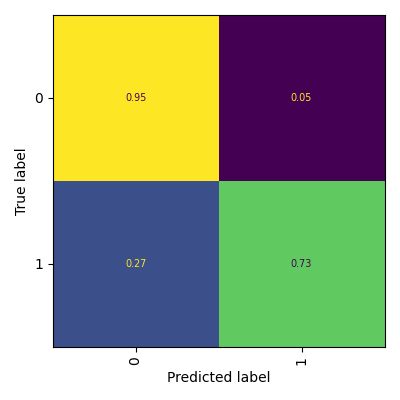

In [16]:
cm = confusion_matrix(targets_pres.to_numpy().flatten(), (predictions>THRESHOLD).to_numpy().flatten(), labels=(0,1), normalize = 'true')
cm = cm.round(2)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=(0,1))
disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax)
plt.tight_layout()
plt.show()
#plt.savefig(pred_path.parent / 'confusion_matrix.png')


#### F1 by site

In [ ]:
# F1 by site

f1scores = []
test_df = fulldf[fulldf['subset'] == 'test']

for site in test_df['site_code'].unique():
    surveys = test_df[test_df['site_code'] == site].index
    lat, lon = test_df.loc[surveys[0], 'latitude'], test_df.loc[surveys[0], 'longitude']
    preds = (predictions > THRESHOLD).astype(float).loc[surveys].to_numpy().flatten()
    targets = (test_df != 0).astype(float).loc[surveys, predictions.columns].to_numpy().flatten()
    f1 = f1_score(targets, preds)
    f1scores.append({'site':site, 'f1':f1, 'lat':lat, 'lon':lon})

pd.DataFrame(f1scores).to_csv(pred_path.parent / 'f1_by_site.csv')


## Best species

#### Extraction

In [4]:
# Calculate average precision

ap = average_precision_score(targets_pres.to_numpy(), predictions.to_numpy(), average=None)

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-pac

In [5]:
aps = pd.DataFrame({"AP":ap, "prev":(targets[predictions.columns] > 0).sum(axis=0)}, index=predictions.columns)
aps.sort_values(ascending=False, by ='AP', inplace = True)
best_species = aps.iloc[0:30]

In [ ]:
# Save to file

best_pred_path = pred_path.parent / 'predictions-probs-best30.csv'

df1 = predictions[list(best_species.index)]
df2 = fulldf[['survey_id', 'latitude', 'longitude', 'depth', 'eventDate']]
pd.concat([df2, df1], axis=1, join="inner").to_csv(best_pred_path)

#### Create input files for additional training (best10 modality)

In [10]:
bestpredspath = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/best30')

def save_line(row):
    np.save(bestpredspath / f"{row.name}.npy", row.values.astype(float))

In [ ]:
best_pred_path = pred_path.parent / 'predictions-probs-best30.csv'
best_pred = pd.read_csv(best_pred_path, index_col='survey_id')
best_species = best_pred.columns[4:]
groundtruth = fulldf.loc[fulldf['subset'] != 'test' , best_species] > 0
to_save = pd.concat([groundtruth, best_pred[best_species]])
to_save.progress_apply(save_line, axis=1)

  0%|          | 0/27437 [00:00<?, ?it/s]

In [ ]:
print(best_species)

#### Plotting

In [ ]:
# Species-specific confusion matrices

i = 0
for s in list(best_species.index):

    # PrecisionRecallDisplay.from_predictions(targets_pres[s].to_numpy(), predictions[s].to_numpy())
    # plt.savefig(f"/home/gaetan/Desktop/predictions/14_humenv_pa-2025-03-04_11-45-preds/PR-curves/{s}.png")

    numbins = 2

    cm = confusion_matrix((targets[s]>0).to_numpy().astype(int), (predictions[s]>0.5).to_numpy().astype(int), labels=range(numbins), normalize = 'true')
    cm = cm.round(3)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"absent (N={len(targets) - targets_prev[s]})", f"present (N={targets_prev[s]})"])
    disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax, cmap = 'Blues')
    disp.ax_.set_title(f"{s} - AP: {best_species.loc[s,'AP']:.2f},\n prevalence = {targets_prev[s]}")
    plt.tight_layout()
    plt.savefig(pred_path.parent / 'cm' / f'{i}_{s}.png')
    #plt.show()
    i += 1

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species_300.csv', index_col = 0)
best_species['genus'] = best_species.index.to_series().apply(lambda x: str(x).split()[0])

px.scatter(best_species, x='prev', y='AP', color='genus')

## Interpretability

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species.csv', index_col = 0)
species = list(best_species.index)
ig_path = pred_path.parent / 'integrated_gradients'

labels = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity"]

#### Per variable density

In [ ]:
colors = plotly.colors.qualitative.Light24

def produce_charts(speci):

    presences = []
    absences = []
    for survey_id in list(targets.index):

        ig = np.load(ig_path / speci / f"ig_{survey_id}.npy")

        abs_ig = np.abs(ig).squeeze()
        averages = abs_ig.mean(axis=(1,2))

        if fulldf.loc[survey_id, s] > 0:
            presences.append(averages)
        else:
            absences.append(averages)

    
    presences = np.vstack(presences)
    absences = np.vstack(absences)

    p = pd.DataFrame(presences)
    a = pd.DataFrame(absences)
    a.columns = labels
    p.columns = labels

    fig = make_subplots(rows=2, cols=1, subplot_titles=("Presence", "Absence"))

    # Plot density for each column
    for i in range(len(a.columns)):
        column = a[s].columns[i]

        density = gaussian_kde(p[column])
        xs = np.linspace(p[column].min(), p[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=1, col=1)

        density = gaussian_kde(a[column])
        xs = np.linspace(a[column].min(), a[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=2, col=1)

    # Update layout
    fig.update_layout(title=speci,
                    xaxis_title='Value',
                    yaxis_title='Density',
                    template='plotly_white',
                    height = 800)

    # Show plot
    fig.update_yaxes(range=[0, 600]) 
    fig.update_xaxes(range=[0, 0.03]) 
    fig.write_image(pred_path.parent / "ig_densities" / f"{s}.png")

In [ ]:
with Pool(processes=18) as pool:
        results = pool.map(produce_charts, species)

#### Summary chart

In [ ]:
series_dict = {}

for i in range(len(species)):
    s = species[i]
    p = Path(output_path / ig_name / "ig_stats" / f"{s}_pres.csv")
    if p.exists():
        df = pd.read_csv(p, index_col = 0)
        series_dict[s] = df['50%']

df = pd.concat(series_dict, axis = 1).T
df.sort_values(ascending=False, by = 'bathymetry_aus', inplace = True)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.T, ax = ax, cbar=False, cmap='YlOrRd')
plt.tight_layout()

## Compare checkpoints

In [ ]:
checkpoints = {'9_env_pa-2025-02-04_16-46-preds' : 'Environment17',
               '10_sat_pa-2025-02-05_17-32-preds' : 'Satellite',
               '11_satenv_pa-2025-02-06_11-50-preds' : 'Environment + Satellite',
               '9_env_pa-2025-03-11_10-31-preds' : 'Environment15',
               '13_hum_pa-2025-03-11_10-29-preds' : 'Human activities',
               '15_humenv_cat_pa-2025-03-11_10-32-preds' : 'Environment + Human activities<br><b>monomodal</b>',
               '14_humenv_pa-2025-03-04_11-45-preds' : 'Environment + Human activities<br><b>multimodal</b>',
               '18_humenv_dhw_cat_pa-2025-05-16_12-02-preds' : 'Envhum+DHW',
               '20_humenv_best10_pa-2025-05-16_14-50-preds' : 'Envhum+Best10',
               '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds': 'Envhum+DHW+Best10',
               }


points = []

for cp in checkpoints:
    try:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions-probs.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    except Exception as e:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    predictions = (predictions >= THRESHOLD).astype(int)

    f1 = f1_score(targets_pres, predictions, average='weighted')
    macacc = balanced_accuracy_score(targets_pres.to_numpy().flatten(), predictions.to_numpy().flatten())
    FP = ((targets_pres == 0) & (predictions == 1)).to_numpy().sum() / (targets_pres == 0).to_numpy().sum()
    FN = ((targets_pres == 1) & (predictions == 0)).to_numpy().sum() / (targets_pres == 1).to_numpy().sum()
    points.append({'f1': f1, 'macro_acc':macacc, 'label': checkpoints[cp], 'False Positives':FP, 'False Negatives':FN})
    

In [ ]:
data = pd.DataFrame(points)
data['size'] = 12

fig = px.scatter(data,
                 x='False Positives',
                 y='False Negatives',
                 color='label',
                 text='label',
                 size = 'size',
                 template='simple_white',
                 width=800,
                 height=1000)

fig.update_layout(showlegend=False)
fig.update_yaxes(   scaleanchor="x",
                    scaleratio=1)
fig.update_traces(textposition='middle right',  textfont=dict(size=20))

fig.show()